<a href="https://colab.research.google.com/github/AiWriter404/AI-With-Python-Digiskills/blob/main/Ai_With_Python_W4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Topic 67 Outlier Detection Using Statistical Rules
# Load Dataset
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
file_path='/content/drive/MyDrive/Ai_with_python/datasets/healthcare_patient_analytics_seaborn.csv'
df=pd.read_csv(file_path)
df.head()

,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01 00:00:00,31-45,Male,West,General Medicine,Medication,Emergency,5.8,59151.0,59.0,0.12
1,2,2022-01-01 01:00:00,60+,Female,West,Orthopedics,Surgery,Routine,5.1,30272.0,97.0,0.11
2,3,2022-01-01 02:00:00,46-60,Male,South,Pediatrics,Observation,Routine,7.9,67498.0,60.0,0.19
3,4,2022-01-01 03:00:00,31-45,Female,North,Neurology,Medication,Routine,5.0,29896.0,51.0,0.47
4,5,2022-01-01 04:00:00,18-30,Female,North,Neurology,Therapy,Routine,0.0,36208.0,60.0,0.40


In [ ]:
print(df.shape)
print(df.columns)

(5000, 12)
Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')


In [ ]:
# IQR method
Q1=df["revenue"].quantile(0.25)
Q3=df["revenue"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers_iqr=df[(df["revenue"]<lower_bound) | (df["revenue"]>upper_bound)]
# IQR interquartile range: measures the middle 50% robust for skewed distribution (like revenue)

In [ ]:
# verify
outliers_iqr.shape

(67, 12)

In [ ]:
outliers_iqr[["revenue","product_category"]].head()

,revenue,product_category
39,3640.56,Home
69,3338.37,Beauty
102,3449.50,Clothing
126,3472.39,Clothing
157,3917.54,Electronics


In [ ]:
df=df[(df["revenue"] >=lower_bound) & (df["revenue"]<=upper_bound)]
df.shape

(4933, 12)

In [ ]:
# Z-score method
from scipy.stats import zscore
df=pd.read_csv(file_path)
df["revenue_zscore"]=zscore(df["revenue"])
outlier_z=df[df["revenue_zscore"].abs()>3]
# Z-score shows how much standard deviations a value is from the mean
# Rule:|Z| > 3 -> outlier

In [ ]:
outlier_z.shape

(26, 13)

In [ ]:
# Topic 68 Correlation & Covariance Analysis
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path='/content/drive/MyDrive/Ai_with_python/datasets/ecommerce_sales_analytics_5000.csv'
df=pd.read_csv(file_path)
df.head()

Mounted at /content/drive


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [ ]:
# Covariance Metric
numeric_df=df[["quantity","unit_price","discount","delivery_days","revenue"]]
print("\nCovariance:\n",numeric_df.cov())
# covariance and corelation used only numerical columns


Covariance:
                   quantity    unit_price   discount  delivery_days  \
quantity          4.082009      0.512237  -0.000881      -0.055733   
unit_price        0.512237  28648.733946   0.226823       8.338403   
discount         -0.000881      0.226823   0.010283      -0.000122   
delivery_days    -0.055733      8.338403  -0.000122       9.943075   
revenue        1040.110589  94746.795528 -11.661466      14.172711   

                     revenue  
quantity         1040.110589  
unit_price      94746.795528  
discount          -11.661466  
delivery_days      14.172711  
revenue        681589.302978  


In [ ]:
# Correlation Matrix
print("\nCorrelation:\n",numeric_df.corr())


Correlation:
                quantity  unit_price  discount  delivery_days   revenue
quantity       1.000000    0.001498 -0.004302      -0.008748  0.623564
unit_price     0.001498    1.000000  0.013215       0.015623  0.678032
discount      -0.004302    0.013215  1.000000      -0.000382 -0.139296
delivery_days -0.008748    0.015623 -0.000382       1.000000  0.005444
revenue        0.623564    0.678032 -0.139296       0.005444  1.000000


In [ ]:
# Focus on Revenue Relationship
numeric_df.corr()["revenue"].sort_values(ascending=False)

,revenue
revenue,1.000000
unit_price,0.678032
quantity,0.623564
delivery_days,0.005444
discount,-0.139296


In [ ]:
# Verification
# Expected minimum > -1 and maximum < +1
numeric_df.corr().values.min(), numeric_df.corr().values.max()

(np.float64(-0.13929560296730714), np.float64(1.0))

In [ ]:
# Topic 69 Creating an Exploratory Data Analysis Report


**EDA Report**
Purpose of EDA Report
1. Summarize key insights from the data
2. Highlight Data Quality issues
3. Identfy Patterns, Distributions and Relationships
4. Include Tables, Figures Summary Statistics
5. Provide a checklist for further analysis

**Activit Goal**

1. Draft a 6 to 8 bullet point summary of your hypothetical EDA findings for a House Prices Dataset

**EDA Summary Points**

1. Comment on Data quality
2. Feature insights
3. Relationship between differnt attributes
4. Categorical insights
5. Outliers Anomolies
6. Temporal Patterns

**Key Takeaways**

1. EDA report = Narrative + visual evidence
2. Use Bullet Points for Clearity
3. Inlcude Tables, Figures and Key matrics
4. Document Assumptions, Anomalies, & Next step

**What is EDA Report**

1. A Short Narrative of Data insights
2. Combines tables, figures and bullet summaries
3. Guides preprocessing and modeling decisions
4. Ensure data quality befor ML
5. EDA report should be concize + structured
6. Use visuals and bullet points for clarity
7. Documents issues insights and next steps
8. Acts as a bridge between raw data and modeling

**Hands-On Examples 6-8 Bullet EDA Summary**


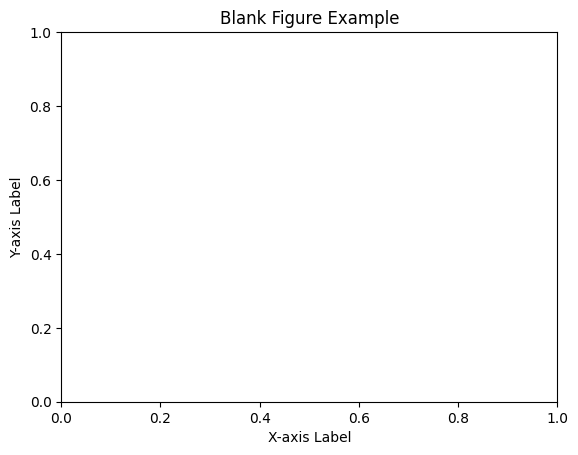

In [ ]:
# Topic 70 Matplotlib Figure Anatomy & Visualization Workflow
import matplotlib.pyplot as plt
# Object oriented workflow
fig, ax=plt.subplots()
# Label Axes
ax.set_title("Blank Figure Example")
ax.set_xlabel("X-axis Label")
ax.set_ylabel("Y-axis Label")
# Save the PNG
fig.savefig("blank_plot.png", dpi=100)
plt.show()

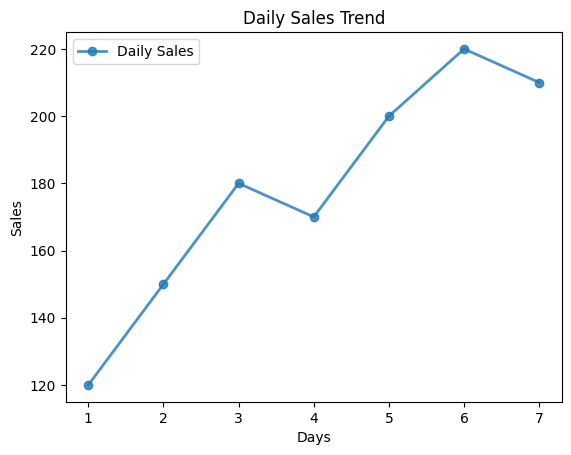

In [ ]:
# Topic 71 Line & Scatter Plots Basics
import matplotlib.pyplot as plt
import pandas as pd
# sample data
days=[1,2,3,4,5,6,7]
sales=[120,150,180,170,200,220,210]
plt.plot(days,sales,
         marker='o',
         linewidth=2,
         alpha=0.8,
         label=("Daily Sales"))
plt.title("Daily Sales Trend")
plt.xlabel("Days")
plt.ylabel("Sales")
plt.legend()

plt.show()

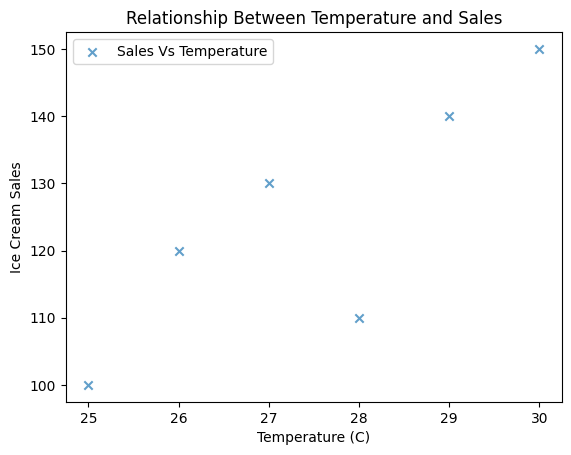

In [ ]:
# Scatter Plot
import matplotlib.pyplot as plt
import pandas as pd
# Samples Data
temperature=[25,26,27,28,29,30]
icecreamsales=[100,120,130,110,140,150]
plt.scatter(temperature,icecreamsales,
            alpha=0.7,
            marker='x',
            label=("Sales Vs Temperature"))
plt.xlabel("Temperature (C)")
plt.ylabel("Ice Cream Sales")
plt.title("Relationship Between Temperature and Sales")
plt.legend()
plt.show()

In [ ]:
# Line Plot Monthlye Revenue Trend
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path='/content/drive/MyDrive/Ai_with_python/datasets/ecommerce_sales_analytics_5000.csv'
df=pd.read_csv(file_path)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [ ]:
df=pd.read_csv(file_path,parse_dates=["order_date"])
df=df.sample(n=100)

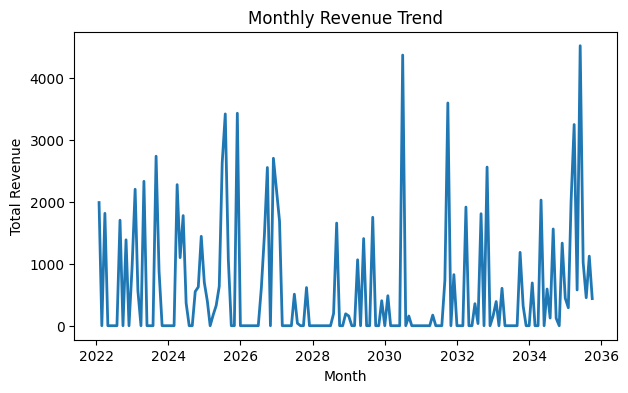

In [ ]:
# Line Plot Monthly Revenue Trend
monthly_revenue=(
    df
    .set_index("order_date")
    .resample("ME")["revenue"]
    .sum()
)
fig, ax=plt.subplots(figsize=(7,4))
ax.plot(monthly_revenue.index, monthly_revenue.values,linewidth=2)
ax.set_title("Monthly Revenue Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue")
plt.show()
# Explanation: line conects revenue over time and shows growth and decline clearly

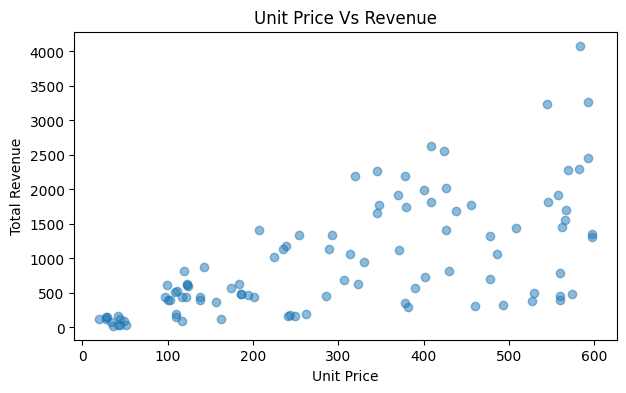

In [ ]:
# Scatter Plot Discount VS Revenue
fig,ax=plt.subplots(figsize=(7,4))
ax.scatter(df["unit_price"],df["revenue"],alpha=0.5)
ax.set_title("Unit Price Vs Revenue")
ax.set_xlabel("Unit Price")
ax.set_ylabel("Total Revenue")
plt.show()
# Each Point = One order and transparecy(alpha) Helps with overlaping points

In [ ]:
# Topic 72 Bar Charts in Matplotlib - Simple, Grouped & Stacked

df=pd.read_csv(file_path,parse_dates=["order_date"])



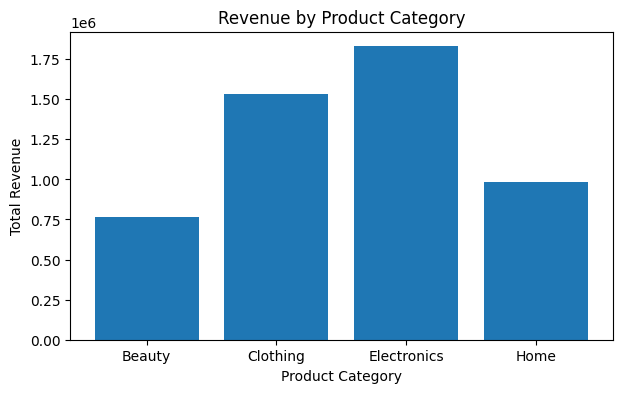

In [ ]:
# Simple Bar Chart Revenue by Product Category
category_revenue=df.groupby("product_category")["revenue"].sum()

fig,ax=plt.subplots(figsize=(7,4))
ax.bar(category_revenue.index,category_revenue.values)

ax.set_title("Revenue by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Revenue")
plt.show()
#

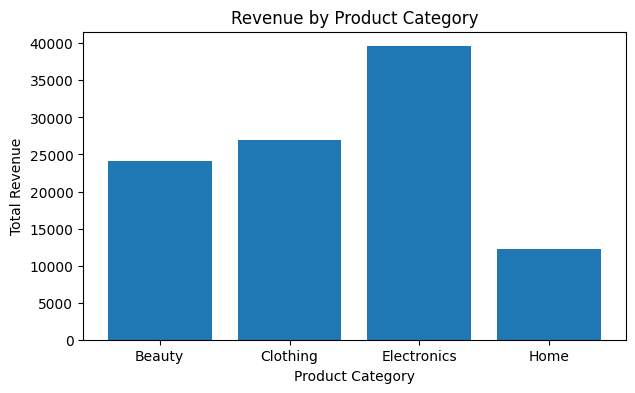

In [ ]:
df=pd.read_csv(file_path,parse_dates=["order_date"])
df=df.sample(n=100)


category_revenue=df.groupby("product_category")["revenue"].sum()

fig,ax=plt.subplots(figsize=(7,4))
ax.bar(category_revenue.index,category_revenue.values)

ax.set_title("Revenue by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Revenue")
plt.show()


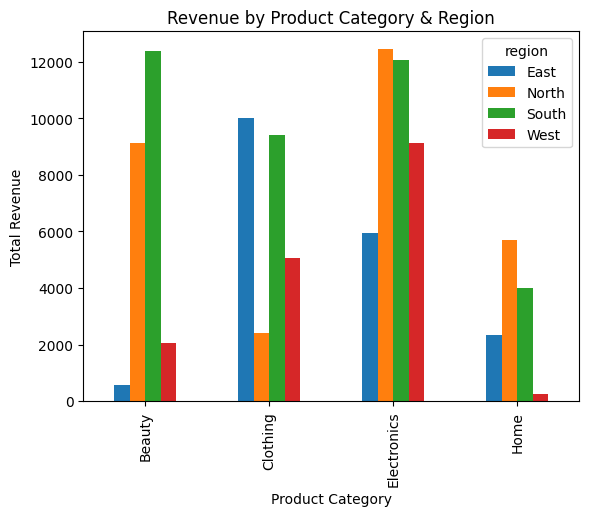

In [ ]:
# Group Bar Revenue By Category & Region
grouped=df.groupby(["product_category","region"])["revenue"].sum().unstack()
grouped.plot(kind="bar",stacked=False)
plt.title("Revenue by Product Category & Region")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.show()

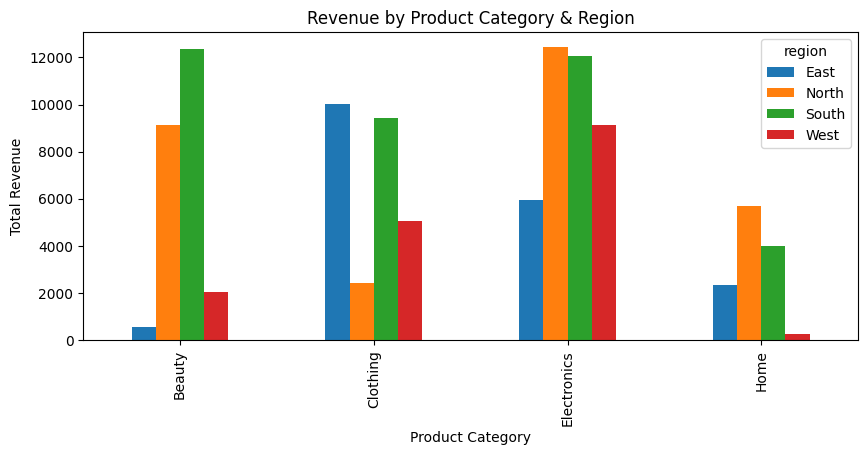

In [ ]:
# Group Bar Revenue By Category & Region
grouped=df.groupby(["product_category","region"])["revenue"].sum().unstack()
grouped.plot(kind="bar",figsize=(10,4))
plt.title("Revenue by Product Category & Region")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.show()

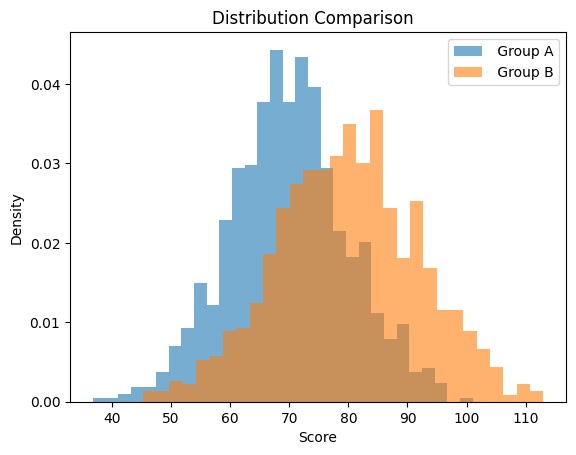

In [ ]:
# Topic 73 Histograms & Density Plots

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

group_a=np.random.normal(70,10,1000)
group_b=np.random.normal(80,12,1000)

plt.hist(group_a, bins=30, density=True,
         alpha=0.6, label=" Group A")
plt.hist(group_b, bins=30, density=True,
         alpha=0.6, label=" Group B")
plt.legend()
plt.xlabel("Score")
plt.ylabel("Density")
plt.title("Distribution Comparison  ")
plt.show()

In [ ]:
# Load Dataset
df=pd.read_csv(file_path,parse_dates=["order_date"])
df=df.sample(n=1000)

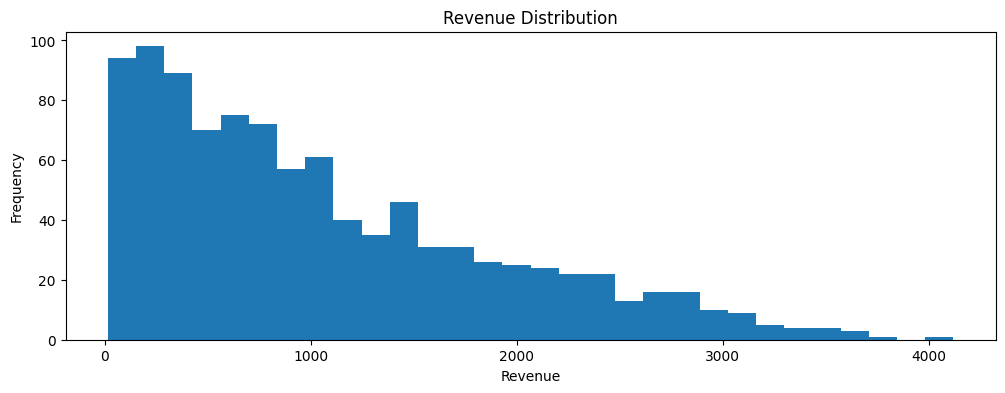

In [ ]:
# Histogram Revenue Distribution
fig,ax=plt.subplots(figsize=(12,4))
ax.hist(df["revenue"], bins=30)

ax.set_title("Revenue Distribution")
ax.set_xlabel("Revenue")
ax.set_ylabel("Frequency")
plt.show()

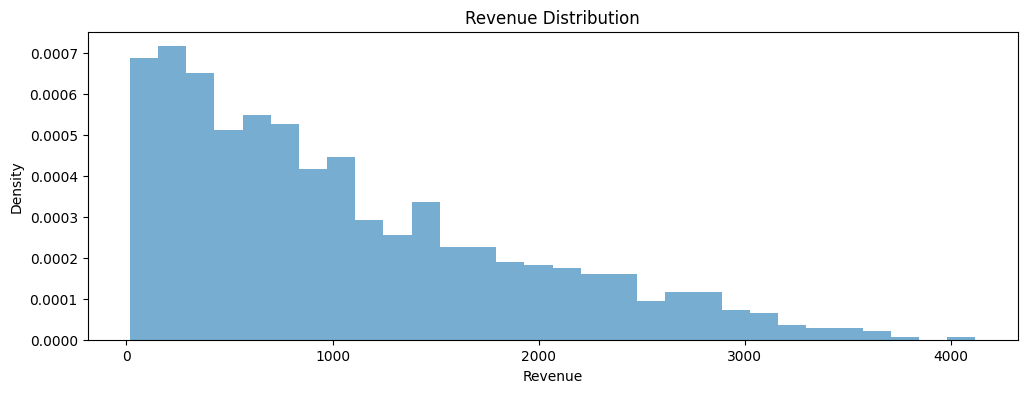

In [ ]:
from IPython.core.pylabtools import figsize
# Density Plot
fig,ax=plt.subplots(figsize=(12,4))
ax.hist(df["revenue"], bins=30, density=True, alpha=0.6)

ax.set_title("Revenue Distribution")
ax.set_xlabel("Revenue")
ax.set_ylabel("Density")
plt.show()
#

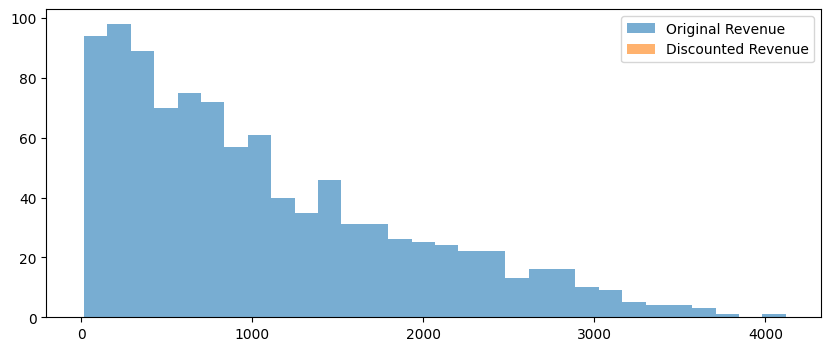

In [ ]:
# Overlay Two Histogram (Comparison) Revenue Vs Discount

discounted_revenue = df["discount"] * (1-df["discount"])

fig,ax=plt.subplots(figsize=(10,4))
ax.hist(df["revenue"], bins=30, alpha=0.6, label="Original Revenue")
ax.hist(discounted_revenue, bins=30, alpha=0.6, label="Discounted Revenue")
ax.legend()
plt.show()

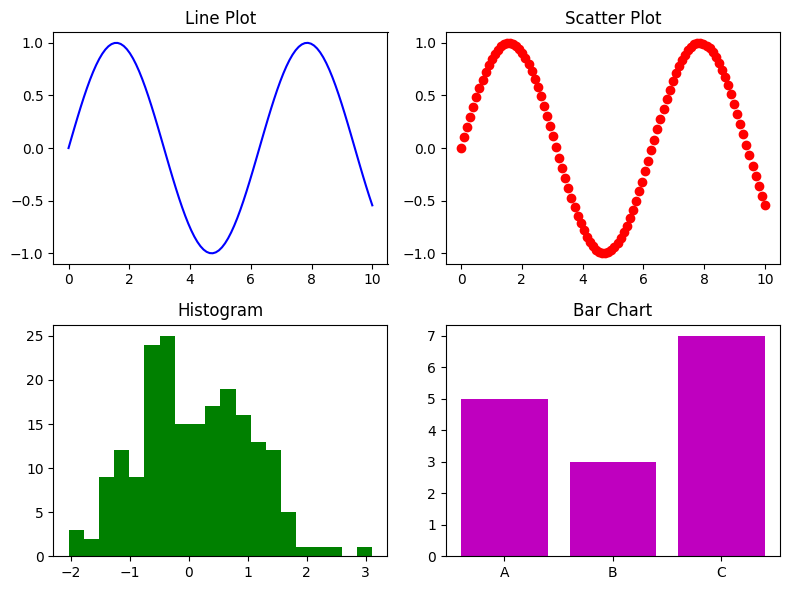

In [ ]:
# Topic 74 Creating Subplots & Layouts

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

x=np.linspace(0,10,100)
y=np.sin(x)
fig, axs=plt.subplots(2,2, figsize=(8,6))

# line plot
axs[0,0].plot(x,y, color="b")
axs[0,0].set_title("Line Plot")

# Scatter plot

axs[0,1].scatter(x,y, color="r")
axs[0,1].set_title("Scatter Plot")

# Histogram
axs[1,0].hist(np.random.randn(200), bins=20, color="g")
axs[1,0].set_title("Histogram")

# Bar Chart
categories=["A","B","C"]
values=[5,3,7]
axs[1,1].bar(categories,values, color="m")
axs[1,1].set_title("Bar Chart")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
file_path='/content/drive/MyDrive/Ai_with_python/datasets/ecommerce_sales_analytics_5000.csv'
df=pd.read_csv(file_path)
parse_dates=["order_date"]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


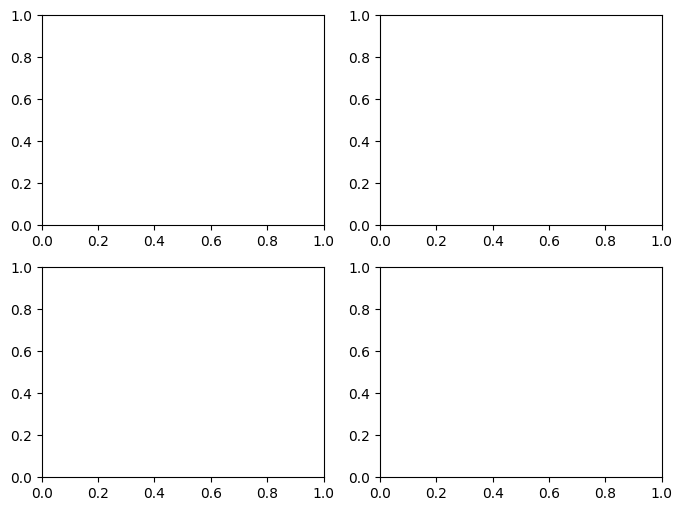

In [ ]:
# Basic Subplots Grid (2x2 example)
fig, axes=plt.subplots(2,2, figsize=(8,6))

In [ ]:
axes[0,0]
axes[1,1]

<Axes: >

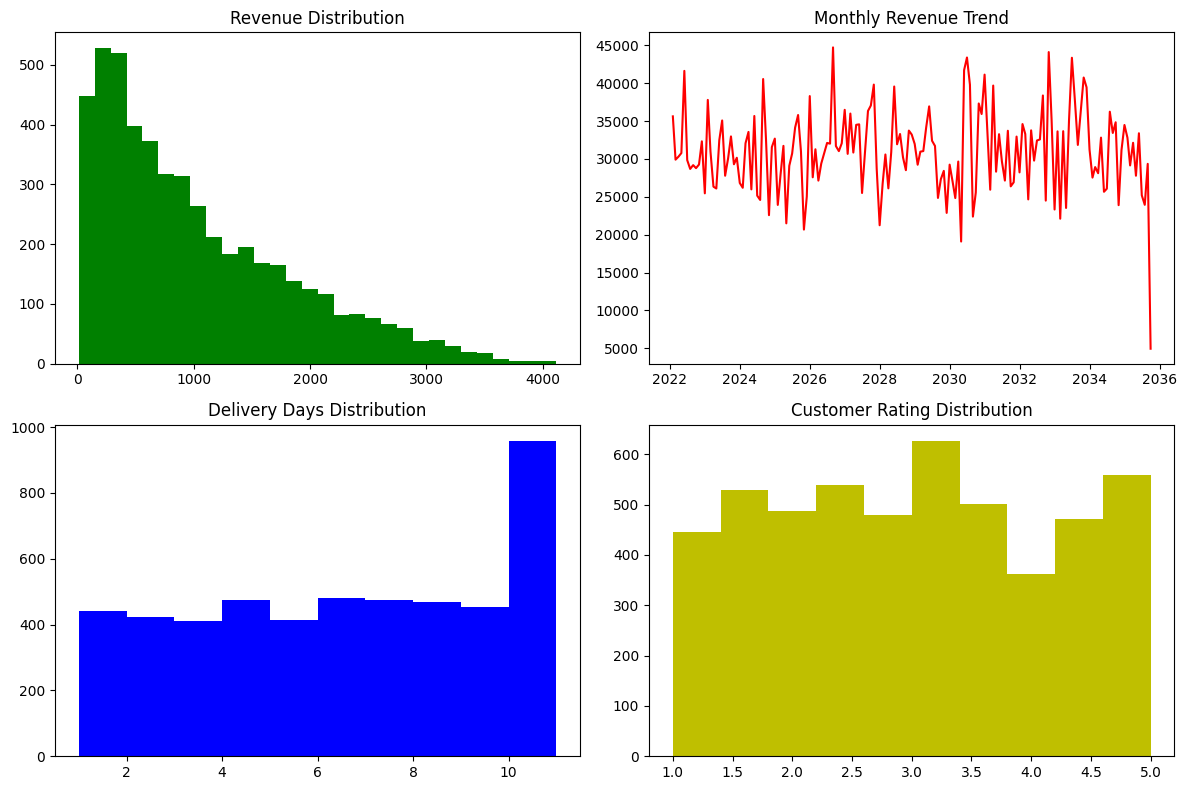

In [ ]:
# Hands on Dashboard Example
df["order_date"] = pd.to_datetime(df["order_date"])
fig, axes=plt.subplots(2,2, figsize=(12,8))
# Revenue distribution
axes[0,0].hist(df["revenue"], bins=30, color="g")
axes[0,0].set_title("Revenue Distribution")
# Monthly Revenue trend
monthly=(
    df.set_index("order_date")["revenue"].resample("ME").sum())

axes[0,1].plot(monthly.index, monthly.values, color="r")
axes[0,1].set_title("Monthly Revenue Trend")

# Delivery Days
axes[1,0].hist(df["delivery_days"], bins=10, color="b")
axes[1,0].set_title("Delivery Days Distribution")

# Customer Rating Distribution
axes[1,1].hist(df["customer_rating"], bins=10, color="y")
axes[1,1].set_title("Customer Rating Distribution")

plt.tight_layout()
plt.show()
#

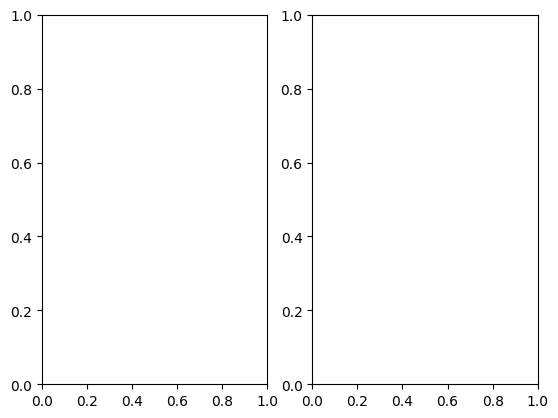

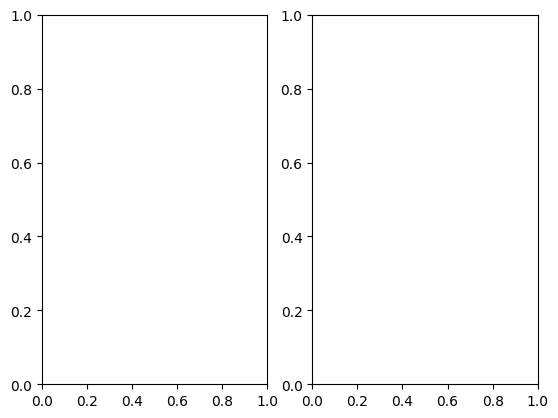

In [ ]:
# Shared Axes (sharex,sharey)
fig, axes=plt.subplots(1,2, sharex=True)
fig, axes=plt.subplots(1,2,sharey=False)
#

In [ ]:
# Layout Management
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

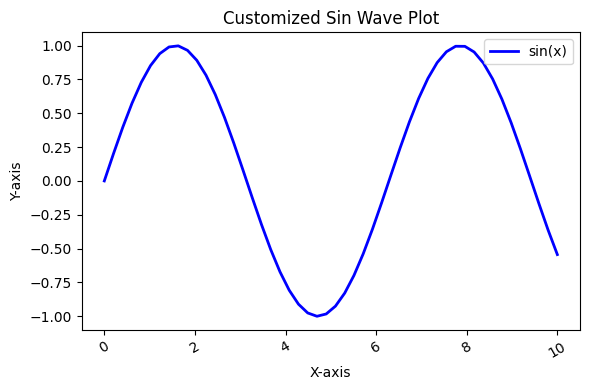

In [ ]:
# Topic 75 Customizing & Exporting Matplotlib Visualizations
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

x=np.linspace(0,10,50)
y=np.sin(x)
fig, ax=plt.subplots(figsize=(6,4))
ax.plot(x,y, label="sin(x)",color="b",linewidth=2)

# Customize Tick and rotation
ax.set_xticks(range(0,11,2))
plt.xticks(rotation=30)

# lagend placement
ax.legend(loc="upper right")

# label and title
ax.set_title("Customized Sin Wave Plot")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")

# Save Polished Figure
plt.tight_layout()
plt.savefig("Sin Plot.png",dpi=300,format="png")
plt.show()

In [ ]:
# Load Dataset
df=pd.read_csv(file_path,parse_dates=["order_date"])
df=df.sample(n=1000)

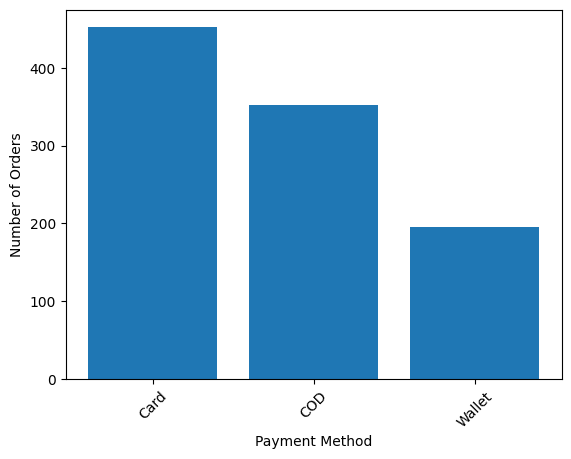

In [ ]:
# Ticks and Tick labels

fig,ax=plt.subplots()
ax.bar(
    df["payment_method"].value_counts().index,
    df["payment_method"].value_counts().values
)
ax.set_xlabel("Payment Method")
ax.set_ylabel("Number of Orders")
ax.tick_params(axis="x", rotation=45)
plt.show()


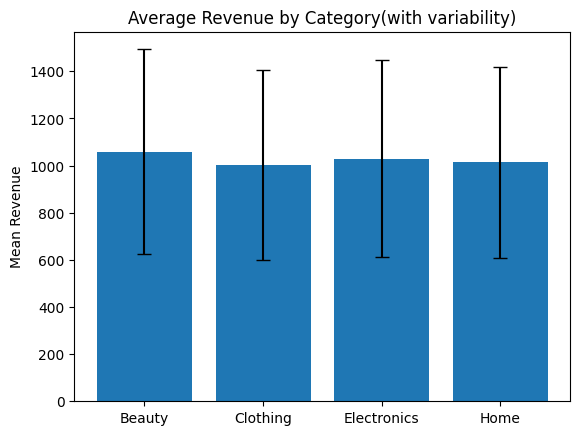

In [ ]:
# Topic 76 Error Bars & Confidence Intervals in Plots

df=pd.read_csv(file_path,parse_dates=["order_date"])

# Error Bars - Mean Revenue and product category

stats=df.groupby("product_category")["revenue"].agg(["mean","std"])
stats["std_error"]=stats["std"]/np.sqrt(stats.shape[0])
fig,ax=plt.subplots()
ax.bar(
    stats.index,
    stats["mean"],
    yerr=stats["std_error"],
    capsize=5
)

ax.set_title("Average Revenue by Category(with variability)")
ax.set_ylabel("Mean Revenue")
plt.show()


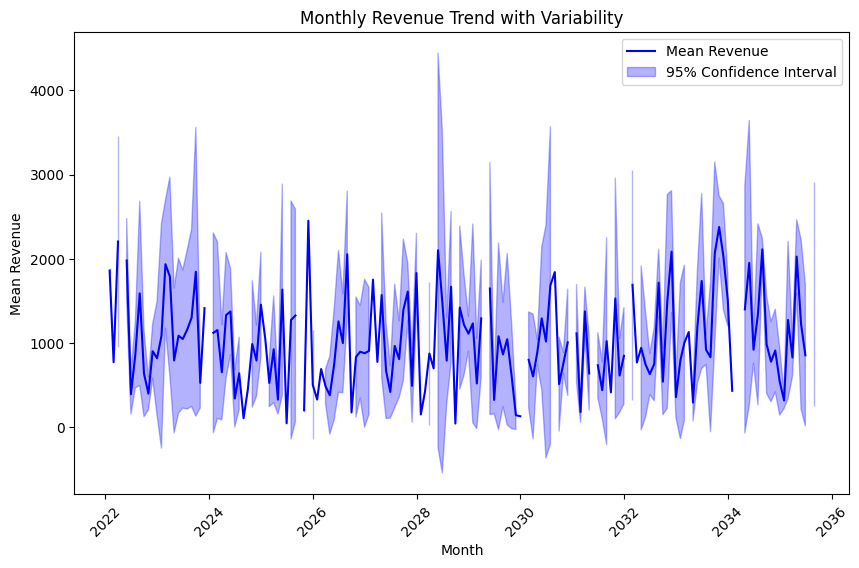

In [ ]:
# Load Dataset
df=pd.read_csv(file_path,parse_dates=["order_date"])
df=df.sample(n=500)

df.head(n=500)

# Confidence Bands Monthly Revenue treds with variability

monthly=(
    df.set_index("order_date")["revenue"]
    .resample("ME")
    .agg(["mean","std"])
)
fig, ax=plt.subplots(figsize=(10,6))
ax.plot(monthly.index, monthly["mean"], color="b", label="Mean Revenue")

ax.fill_between(
    monthly.index,
    monthly["mean"]-monthly["std"],
    monthly["mean"]+monthly["std"],
    color="b",
    alpha=0.3,
    label="95% Confidence Interval"
)
ax.tick_params(axis="x", rotation=45)
ax.set_title("Monthly Revenue Trend with Variability")
ax.set_xlabel("Month")
ax.set_ylabel("Mean Revenue")
ax.legend()
plt.show()
#

In [ ]:
# Topic 77 Introduction to Seaborn Visualization Library



**Seaborn OverView**

1.   Part of Python's Data Visualization ecosystem
2.   Widely uses in Ai and DataScience Pipelines.
3.   Clear Visual with minimum use of code.
4.   Built-in themes and color palletes wide range.
5.   Availibility of high level Statistical plots.
6.   Ideal for EDA in AI and ML pipelines.

**Seaborn Key Features**


1.   Provide Us High-level Plotting Functions (e.g.,sns.distplot, scatterplots).
2.   Automatic Handling of Pandas DataFrame.
3.   Built-in Themes darkgrid, whitegrid, dark, white and ticks.
4.   Seamlessly Integration with numpy and pandas and matplotlib.
5.   Provide Quick visual mapping for understanding the data.






In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
file_path='/content/drive/MyDrive/Ai_with_python/datasets/healthcare_patient_analytics_seaborn.csv'
df=pd.read_csv(file_path)
df.head()

,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01 00:00:00,31-45,Male,West,General Medicine,Medication,Emergency,5.8,59151.0,59.0,0.12
1,2,2022-01-01 01:00:00,60+,Female,West,Orthopedics,Surgery,Routine,5.1,30272.0,97.0,0.11
2,3,2022-01-01 02:00:00,46-60,Male,South,Pediatrics,Observation,Routine,7.9,67498.0,60.0,0.19
3,4,2022-01-01 03:00:00,31-45,Female,North,Neurology,Medication,Routine,5.0,29896.0,51.0,0.47
4,5,2022-01-01 04:00:00,18-30,Female,North,Neurology,Therapy,Routine,0.0,36208.0,60.0,0.40


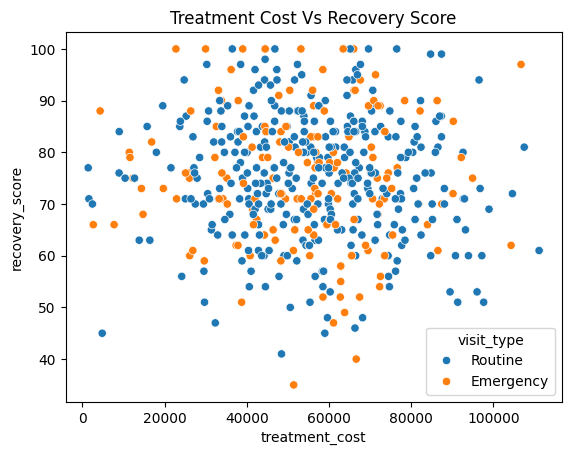

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=df.sample(500)

# Axes level example (scatterplot)

sns.scatterplot(
    data=df,
    x="treatment_cost",
    y="recovery_score",
    hue="visit_type"
)
plt.title("Treatment Cost Vs Recovery Score")
plt.show()

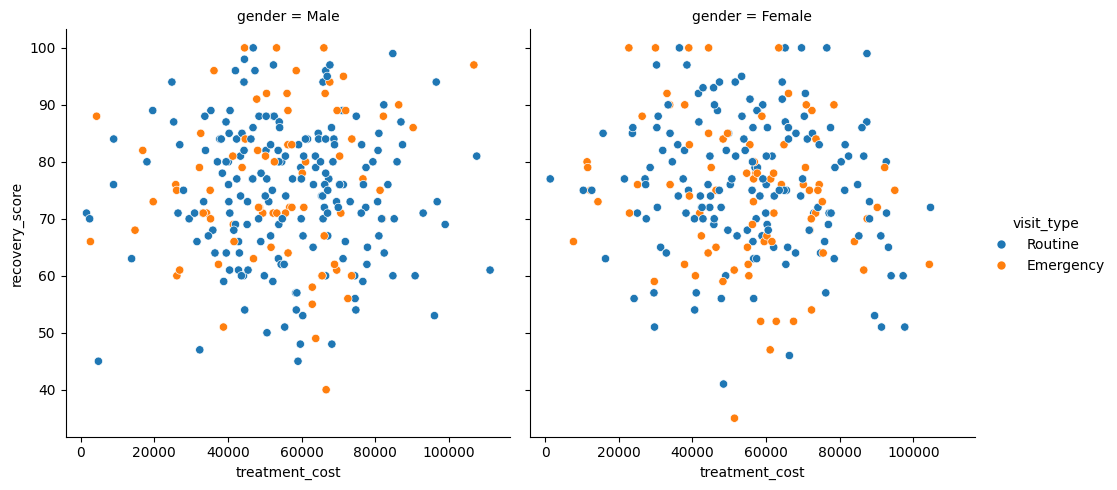

In [ ]:
# Figure level Example (replot)
sns.relplot(
    data=df,
    x="treatment_cost",
    y="recovery_score",
    hue="visit_type",
    col="gender"
)
plt.show()

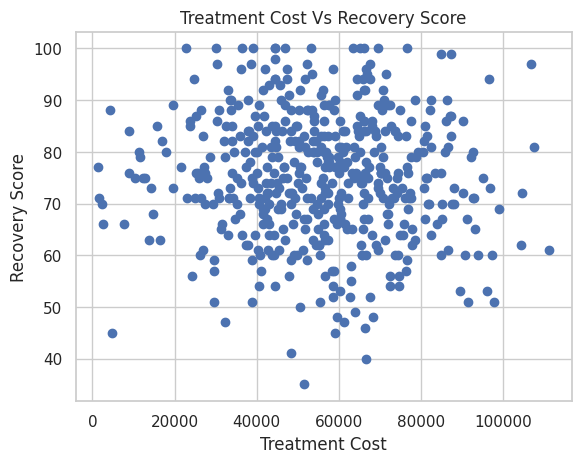

<Axes: xlabel='treatment_cost', ylabel='recovery_score'>

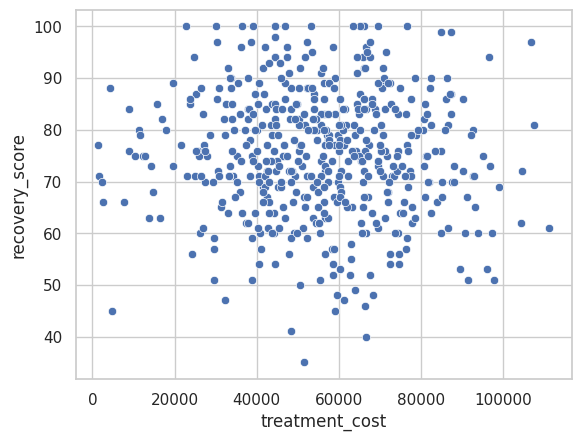

In [ ]:
# Apply Theme in Seaborn

sns.set_theme(style="whitegrid")

# Recreating a matplotlib plot in seaborn

# Matplotlib
plt.scatter(df["treatment_cost"],df["recovery_score"])
plt.xlabel("Treatment Cost")
plt.ylabel("Recovery Score")
plt.title("Treatment Cost Vs Recovery Score")
plt.show()

# Seaborn
sns.scatterplot(
    data=df,
    x="treatment_cost",
    y="recovery_score",

)

In [ ]:
# Topic 78 Distribution Plots - histplot & kdeplot
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
file_path='/content/drive/MyDrive/Ai_with_python/datasets/healthcare_patient_analytics_seaborn.csv'
df=pd.read_csv(file_path)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01 00:00:00,31-45,Male,West,General Medicine,Medication,Emergency,5.8,59151.0,59.0,0.12
1,2,2022-01-01 01:00:00,60+,Female,West,Orthopedics,Surgery,Routine,5.1,30272.0,97.0,0.11
2,3,2022-01-01 02:00:00,46-60,Male,South,Pediatrics,Observation,Routine,7.9,67498.0,60.0,0.19
3,4,2022-01-01 03:00:00,31-45,Female,North,Neurology,Medication,Routine,5.0,29896.0,51.0,0.47
4,5,2022-01-01 04:00:00,18-30,Female,North,Neurology,Therapy,Routine,0.0,36208.0,60.0,0.40


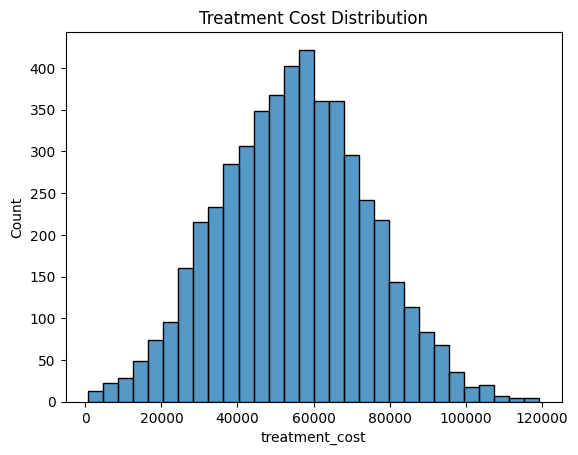

In [ ]:
# Histplot
# Senario treatment cost distribution
sns.histplot(
    data=df,
    x="treatment_cost",
    bins=30
)
plt.title("Treatment Cost Distribution")
plt.show()

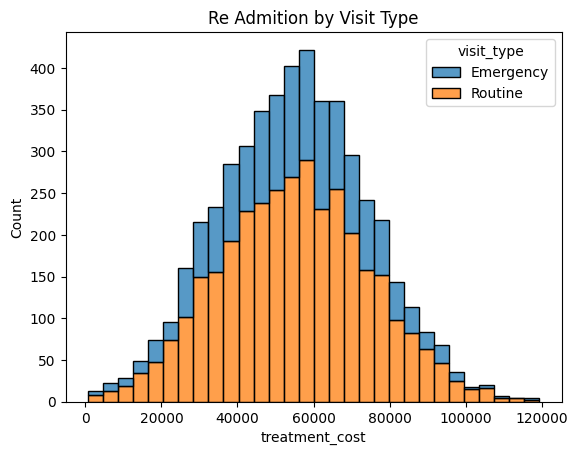

In [ ]:
# Comparison Distribution Across Categories
# senario Routine vs emergency visits
sns.histplot(
    data=df,
    x="treatment_cost",
    hue="visit_type",
    multiple="stack",
    bins=30

)
plt.title("Re Admition by Visit Type")
plt.show()

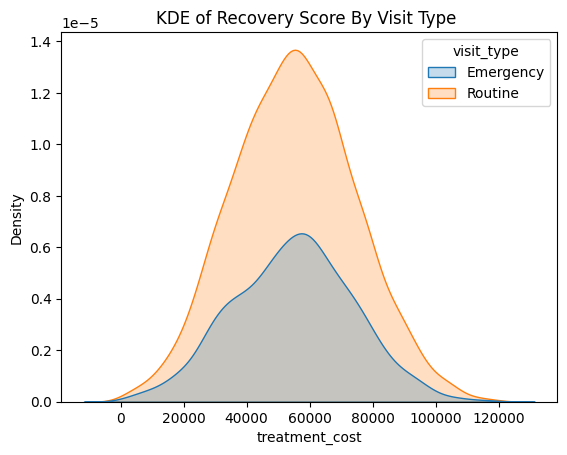

In [ ]:
# Kdeplot - provides a smooth estimate of the distribution
sns.kdeplot(
    data=df,
    x="treatment_cost",
    hue="visit_type",
    # multiple="stack"
    fill=True,
    # alpha=0.5

)
plt.title("KDE of Recovery Score By Visit Type ")
plt.show()

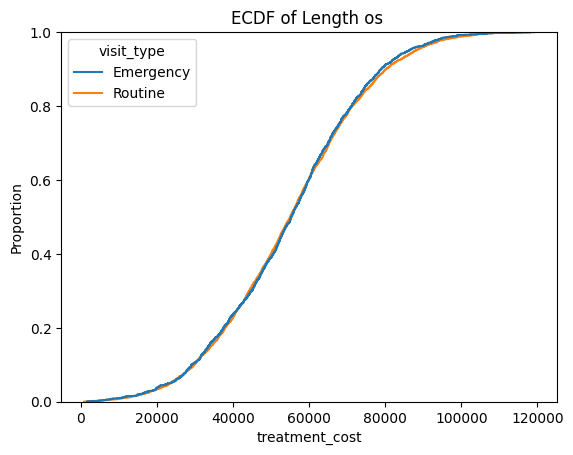

In [ ]:
# ECDF shows cumulative proportion
sns.ecdfplot(
    data=df,
    x="treatment_cost",
    hue="visit_type"

)
plt.title("ECDF of Length os ")
plt.show()

In [ ]:
# Topic 79 Categorical Data Visualization with Seaborn
# Load The Healthcare Dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
file_path='/content/drive/MyDrive/Ai_with_python/datasets/healthcare_patient_analytics_seaborn.csv'
df=pd.read_csv(file_path)
df.head()

,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,1,2022-01-01 00:00:00,31-45,Male,West,General Medicine,Medication,Emergency,5.8,59151.0,59.0,0.12
1,2,2022-01-01 01:00:00,60+,Female,West,Orthopedics,Surgery,Routine,5.1,30272.0,97.0,0.11
2,3,2022-01-01 02:00:00,46-60,Male,South,Pediatrics,Observation,Routine,7.9,67498.0,60.0,0.19
3,4,2022-01-01 03:00:00,31-45,Female,North,Neurology,Medication,Routine,5.0,29896.0,51.0,0.47
4,5,2022-01-01 04:00:00,18-30,Female,North,Neurology,Therapy,Routine,0.0,36208.0,60.0,0.40


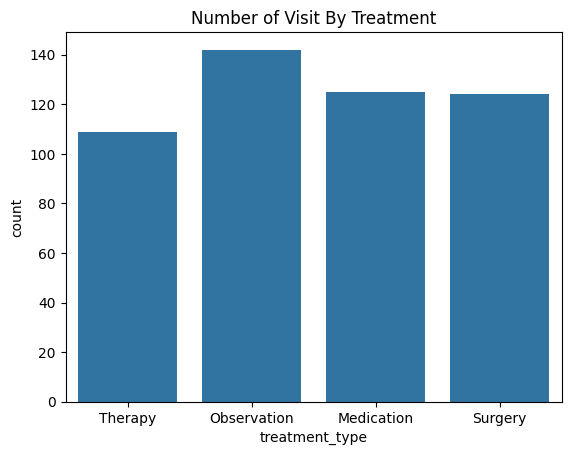

In [ ]:
df=df.sample(500)
# barplot vs countplot
# count plot
sns.countplot(
    data=df,
    x="treatment_type"

)
plt.title("Number of Visit By Treatment")
plt.show()

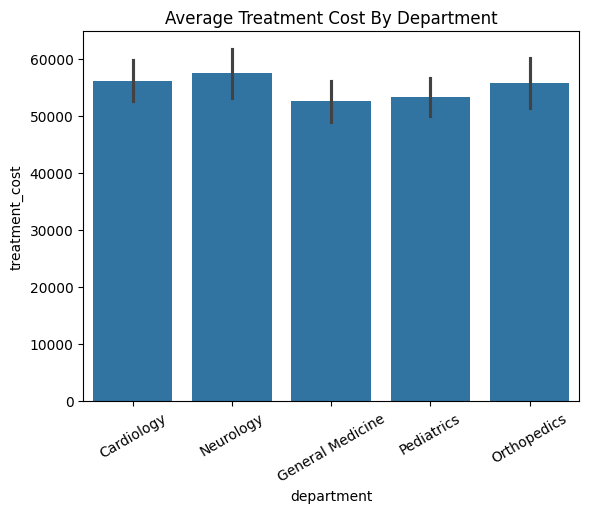

In [ ]:
# barplot vs Countplot
# barplot
sns.barplot(
    data=df,
    x="department",
    y="treatment_cost"

)

plt.xticks(rotation=30)
plt.title("Average Treatment Cost By Department")
plt.show()

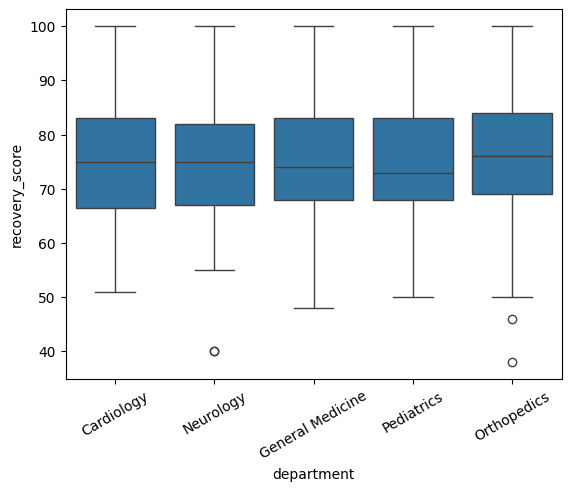

In [ ]:
# Distribution Based Categoricla Plots
# Boxplot shows median quartiles and outliers
sns.boxplot(
    data=df,
    x="department",
    y="recovery_score"
)
plt.xticks(rotation=30)
plt.show( )

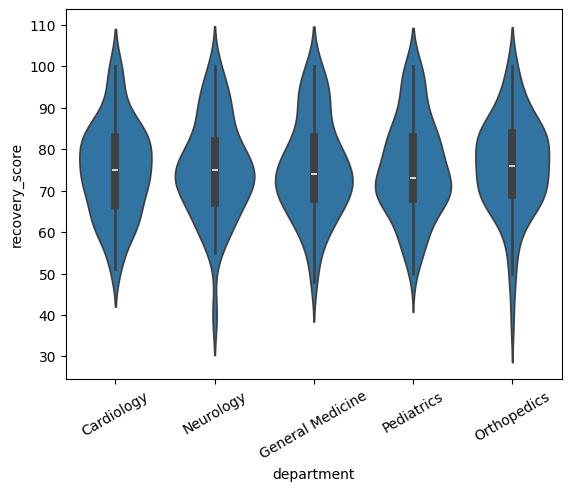

In [ ]:
# Distribution Based Categoricla Plots
# violon plot show full distribution shapes
sns.violinplot(
    data=df,
    x="department",
    y="recovery_score"
)
plt.xticks(rotation=30)
plt.show()

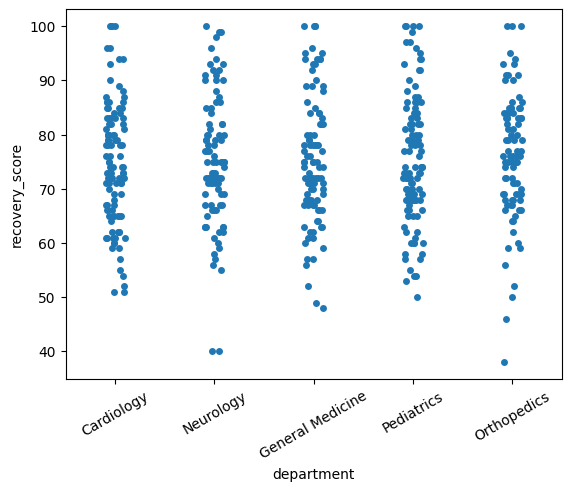

In [ ]:
# Distribution Based Categoricla Plots
# swarm strip plot shows indivisual data points
sns.stripplot(
    data=df,
    x="department",
    y="recovery_score",
    jitter=True
)
plt.xticks(rotation=30)
plt.show()

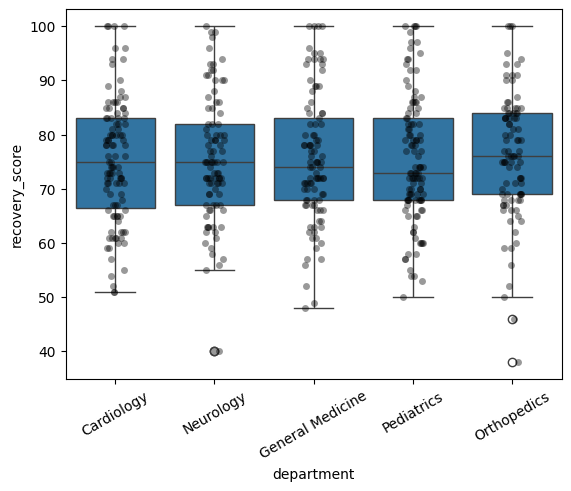

In [ ]:
# Side by side Comparison (Box + Strip plot)
sns.boxplot(
    data=df,
    x="department",
    y="recovery_score"
)
sns.stripplot(
    data=df,
    x="department",
    y="recovery_score",
    jitter=True,
    color="black" ,
    alpha=0.4
)
plt.xticks(rotation=30)
plt.show()

In [ ]:
# Topic 80 Heatmaps & Correlation Visualization
file_path='/content/drive/MyDrive/Ai_with_python/datasets/healthcare_patient_analytics_seaborn.csv'
df=pd.read_csv(file_path)
numeric_df=df["length_of_stay_days","treatment_cost","recovery_score","readmission_risk"]


SyntaxError: incomplete input (1511292222.py, line 5)

In [ ]:
# Correlation Metrics
corr_matrix=numeric_df.corr()
corr_matrix

,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
length_of_stay_days,1.000000,-0.022281,0.012183,-0.000935
treatment_cost,-0.022281,1.000000,-0.014562,0.017822
recovery_score,0.012183,-0.014562,1.000000,0.002052
readmission_risk,-0.000935,0.017822,0.002052,1.000000


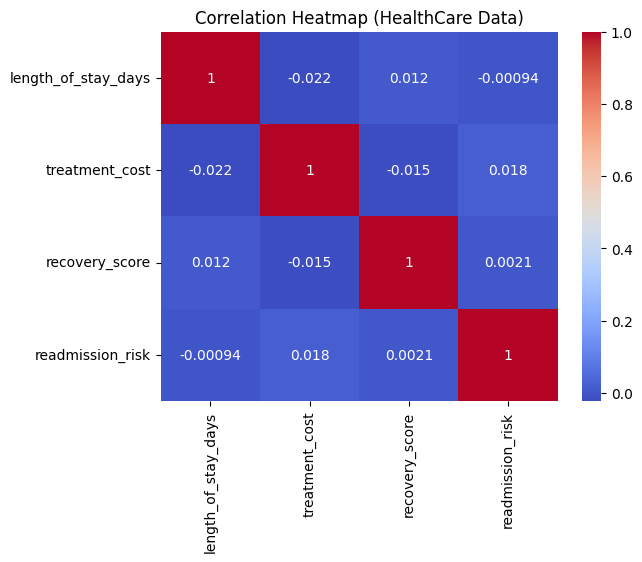

In [ ]:
# Heatmap basic visualization
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap (HealthCare Data)")
plt.show()

In [ ]:
# Masking Upar Triangle
import numpy as np
mask=np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap (Masked)")
plt.show()

NameError: name 'corr_matrix' is not defined

In [ ]:
# Topic 81 Encoding Categorical Variables
# Sample Dataset
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.DataFrame({
    "City":["New York","London","Paris","Tokyo","New York","Paris"],
    "Segment":["A","B","A","A","B","B"],
    "Sales":[100,150,200,120,180,220]
})
print(df)

       City Segment  Sales
0  New York       A    100
1    London       B    150
2     Paris       A    200
3     Tokyo       A    120
4  New York       B    180
5     Paris       B    220


In [ ]:
# One Hot incode
encoded = pd.get_dummies(df, columns=["City", "Segment"],drop_first=False)
print(encoded)

   Sales  City_London  City_New York  City_Paris  City_Tokyo  Segment_A  \
0    100        False           True       False       False       True   
1    150         True          False       False       False      False   
2    200        False          False        True       False       True   
3    120        False          False       False        True       True   
4    180        False           True       False       False      False   
5    220        False          False        True       False      False   

   Segment_B  
0      False  
1       True  
2      False  
3      False  
4       True  
5       True  


In [ ]:
from sklearn.preprocessing import OrdinalEncoder
df2=pd.DataFrame({
    "Size":["Small","Medium","Large","Small","Medium"]
})
print(df2)

     Size
0   Small
1  Medium
2   Large
3   Small
4  Medium


In [ ]:
encoder=OrdinalEncoder(categories=[["Small","Medium","Large"]])
df2["Size_encoded"]=encoder.fit_transform(df2[["Size"]])
print(df2)

     Size  Size_encoded
0   Small           0.0
1  Medium           1.0
2   Large           2.0
3   Small           0.0
4  Medium           1.0


In [2]:
# Topic 82 Feature Scaling & Normalization
import pandas as pd
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
drive.mount('/content/drive')
file_path='/content/drive/MyDrive/Ai_with_python/datasets/telecom_customer_churn_feature_engineering.csv'
df=pd.read_csv(file_path)
df.head()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
0,10001,2019-01-01,65,Male,Multan,Bachelor,Employed,57643.0,10049.0,5.8,52.0,6-Month,1,Coverage is poor in my location,0
1,10002,2019-01-02,22,Female,Peshawar,Master,Employed,18207.0,2752.0,11.9,22.0,6-Month,2,Billing issues occurred multiple times,0
2,10003,2019-01-03,43,Male,Gujranwala,Secondary,Employed,13075.0,3155.0,40.0,87.0,Monthly,0,Billing issues occurred multiple times,0
3,10004,2019-01-04,21,Male,Lahore,Secondary,Employed,38890.0,5859.0,8.5,147.0,6-Month,2,Customer support was helpful,0
4,10005,2019-01-05,37,Female,Hyderabad,Primary,Employed,17475.0,5106.0,3.3,183.0,12-Month,0,Coverage is poor in my location,0


In [3]:
# inspect row values
df[["monthly_income","monthly_bill"]].head()
# income and bill are very different scale

,monthly_income,monthly_bill
0,57643.0,10049.0
1,18207.0,2752.0
2,13075.0,3155.0
3,38890.0,5859.0
4,17475.0,5106.0


In [4]:
# why scaling is required
df[["monthly_income","monthly_bill"]].describe()
# income dominates numerical - models will focus more on income than bill

,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1200 non-null   int64  
 1   signup_date        1200 non-null   object 
 2   age                1200 non-null   int64  
 3   gender             1200 non-null   object 
 4   city               1200 non-null   object 
 5   education_level    1200 non-null   object 
 6   employment_status  1200 non-null   object 
 7   monthly_income     1200 non-null   float64
 8   monthly_bill       1200 non-null   float64
 9   internet_usage_gb  1200 non-null   float64
 10  call_minutes       1200 non-null   float64
 11  contract_type      1200 non-null   object 
 12  support_tickets    1200 non-null   int64  
 13  customer_feedback  1200 non-null   object 
 14  churn              1200 non-null   int64  
dtypes: float64(4), int64(4), object(7)
memory usage: 140.8+ KB


In [ ]:
# z score scalling standrization (manual)
# 1 calculate mean and std
income_mean=df["monthly_income"].mean()
income_std=df["monthly_income"].std()
print("Mean:", income_mean)
print("Std:", income_std)

Mean: 31155.975833333334
Std: 19351.937725889493


In [ ]:
# 2 Apply z-score formula
df["income_zscore"]=(df["monthly_income"]-income_mean)/income_std
df[["monthly_income","income_zscore"]].head()

,monthly_income,income_zscore
0,57643.0,1.368701
1,18207.0,-0.669131
2,13075.0,-0.934324
3,38890.0,0.399651
4,17475.0,-0.706956


In [ ]:
# verify z-score scaling
df["income_zscore"].mean(), df["income_zscore"].std()


(np.float64(-1.628327102783563e-17), 0.9999999999999997)

In [ ]:
# Apply Mean Max Formula
df["bill_minmax"] = (df["monthly_bill"] - df["monthly_bill"].min()) / (df["monthly_bill"].max() - df["monthly_bill"].min())
df[["monthly_bill", "bill_minmax"]].head()

,monthly_bill,bill_minmax
0,10049.0,0.261956
1,2752.0,0.057277
2,3155.0,0.068582
3,5859.0,0.144428
4,5106.0,0.123306


In [ ]:
# verify min and max scaling
df["bill_minmax"].min(), df["bill_minmax"].max()

(0.0, 1.0)

In [ ]:
# show minimum, maximum and midle value together
df.loc[
    [df["monthly_bill"].idxmin(),
     df["monthly_bill"].idxmax(),
     df["monthly_bill"].sort_values().index[len(df)//2]
     ],
     ["monthly_bill","bill_minmax"]
     ]

,monthly_bill,bill_minmax
893,710.0,0.000000
968,36361.0,1.000000
47,4873.0,0.116771


In [ ]:
# side by side comparison
df[["monthly_bill","income_zscore",
    "monthly_bill","bill_minmax"]].head()

,monthly_bill,income_zscore,monthly_bill,bill_minmax
0,10049.0,1.368701,10049.0,0.261956
1,2752.0,-0.669131,2752.0,0.057277
2,3155.0,-0.934324,3155.0,0.068582
3,5859.0,0.399651,5859.0,0.144428
4,5106.0,-0.706956,5106.0,0.123306


In [ ]:
# Data Leakage - Wrong (scaling before split)
df_scaled_wrong=(df["monthly_income"]-df["monthly_income"].mean())/df["monthly_income"].std()
df_scaled_wrong.head()

,monthly_income
0,1.368701
1,-0.669131
2,-0.934324
3,0.399651
4,-0.706956


In [ ]:
# Topic 83 Feature Transformations
df=pd.read_csv(file_path)

In [ ]:
# see the problem
df[["monthly_income","monthly_bill"]].describe()

,monthly_income,monthly_bill
count,1200.000000,1200.000000
mean,31155.975833,5939.150833
std,19351.937726,4046.473963
min,4984.000000,710.000000
25%,17795.000000,3291.750000
50%,26628.000000,4871.000000
75%,39886.250000,7485.500000
max,209790.000000,36361.000000


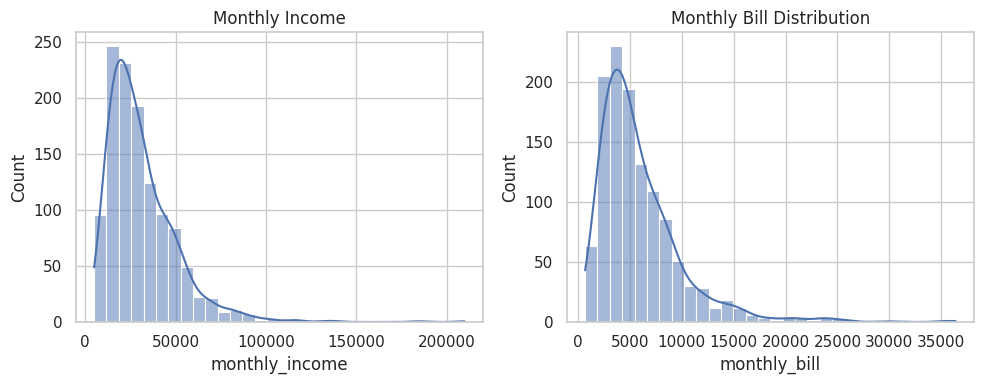

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)

sns.histplot(df["monthly_income"], kde=True, bins=30)

plt.title("Monthly Income")

plt.subplot(1,2,2)

sns.histplot(df["monthly_bill"],kde=True, bins=30)

plt.title("Monthly Bill Distribution")

plt.tight_layout()
plt.show()



In [7]:
# safe log transformation
import numpy as np
df["income_log"] =np.log1p(df["monthly_income"])
df[["monthly_income","income_log"]].head()

,monthly_income,income_log
0,57643.0,10.962041
1,18207.0,9.809616
2,13075.0,9.478534
3,38890.0,10.568518
4,17475.0,9.768584


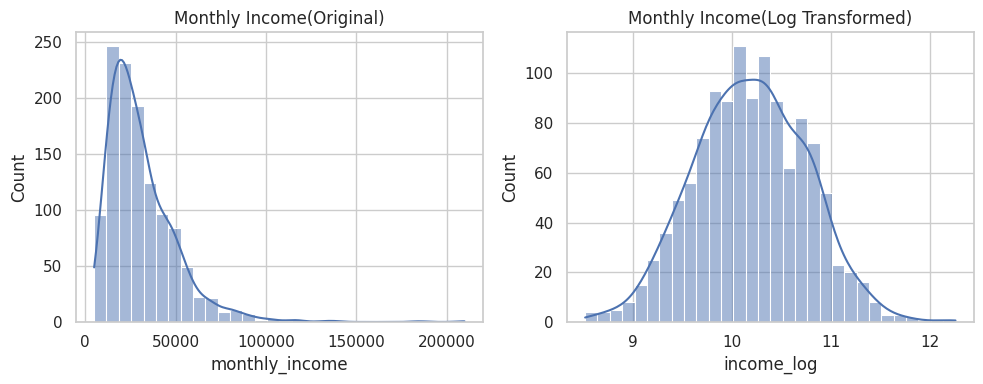

In [9]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)

sns.histplot(df["monthly_income"], kde=True, bins=30)

plt.title("Monthly Income(Original)")

plt.subplot(1,2,2)

sns.histplot(df["income_log"],kde=True, bins=30)

plt.title("Monthly Income(Log Transformed)")

plt.tight_layout()
plt.show()

In [12]:
# Clipping
upper_limit=df["monthly_bill"].quantile(0.99)
lower_limit=df["monthly_bill"].quantile(0.01)
df["bill_clipped"]=df["monthly_bill"].clip(lower_limit,upper_limit)
df.loc[
    [df["monthly_bill"].idxmax(),
     df["monthly_bill"].sort_values().index[len(df)//2],
     #df["monthly_bill"].idxmin()
     ],
     ["monthly_bill","bill_clipped"]
]

,monthly_bill,bill_clipped
968,36361.0,21696.4
47,4873.0,4873.0


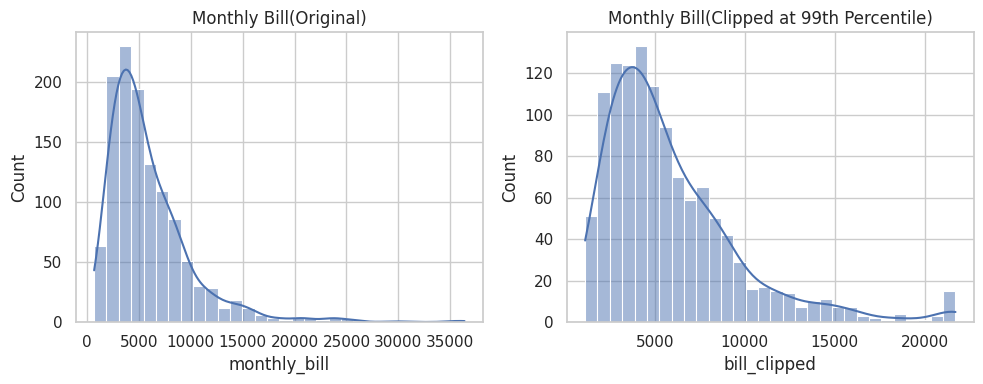

In [14]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)

sns.histplot(df["monthly_bill"], kde=True, bins=30)

plt.title("Monthly Bill(Original)")

plt.subplot(1,2,2)

sns.histplot(df["bill_clipped"],kde=True, bins=30)

plt.title("Monthly Bill(Clipped at 99th Percentile)")

plt.tight_layout()
plt.show()

In [18]:
from scipy.stats.mstats import winsorize
# winzorize cap only the top 10
df["bill_winsorized"]=winsorize(df["monthly_bill"],limits=[0.01,0.01])
# lower cap upper cap
# Check effects on extreme values
df.loc[
    [df["monthly_bill"].idxmin(),
    # df["monthly_bill"].sort_values().index[len(df)//2],
     df["monthly_bill"].idxmax()
     ],
     ["monthly_bill","bill_winsorized"]
]

,monthly_bill,bill_winsorized
893,710.0,1140.0
968,36361.0,21682.0


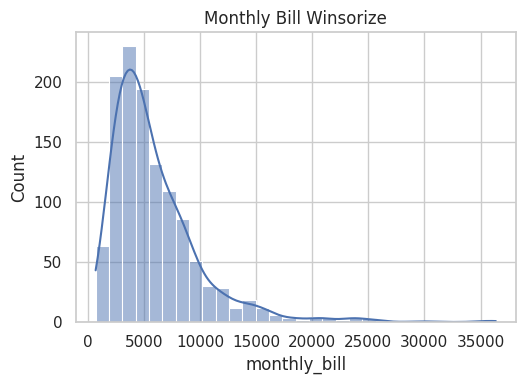

In [19]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)

sns.histplot(df["monthly_bill"], kde=True, bins=30)

plt.title("Monthly Bill Winsorize")
plt.tight_layout()
plt.show()

In [ ]:
# Week Complete